# Übungsaufgaben Session 1

### Aufgabe 1
Nutzt das in der Vorlesungen besprochenen theoretische und praktische Vorgehen zur Anwendung der Linearen Regression in Python basierend auf den Daten in birthweight_data.csv. Das Gewicht bei Geburt des Kindes ist hier als Output-Variable zu nutzen.

In [1]:
import pandas as pd
import numpy as np
import sklearn
import io
from sklearn import linear_model
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
birthweight_data = pd.read_csv("birthweight_data.csv")
birthweight_data

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,bwghtlbs
0,13.5,16.5,122.300003,109,12.0,12.0,1,1,1,0,6.8125
1,7.5,16.5,122.300003,133,6.0,12.0,2,1,0,0,8.3125
2,0.5,16.5,122.300003,129,NaN,12.0,2,0,0,0,8.0625
3,15.5,16.5,122.300003,126,12.0,12.0,2,1,0,0,7.8750
4,27.5,16.5,122.300003,134,14.0,12.0,2,1,1,0,8.3750
...,...,...,...,...,...,...,...,...,...,...,...
1383,27.5,30.0,138.300003,110,12.0,12.0,4,1,1,0,6.8750
1384,5.5,30.0,138.300003,146,NaN,16.0,2,1,1,0,9.1250
1385,65.0,8.0,118.599998,135,18.0,16.0,2,0,1,0,8.4375
1386,27.5,8.0,118.599998,118,NaN,14.0,2,0,1,0,7.3750


In [3]:
birthweight_data.describe()

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,bwghtlbs
count,1388.000000,1388.000000,1388.000000,1388.000000,1192.000000,1387.000000,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000
mean,29.026657,19.552954,130.559006,118.699568,13.186242,12.935833,1.632565,0.520893,0.784582,2.087176,7.418723
std,18.739285,7.795598,10.244485,20.353964,2.745985,2.376728,0.894027,0.499743,0.411260,5.972688,1.272123
min,0.500000,2.000000,103.800003,23.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.437500
25%,14.500000,15.000000,122.800003,107.000000,12.000000,12.000000,1.000000,0.000000,1.000000,0.000000,6.687500
50%,27.500000,20.000000,130.800003,120.000000,12.000000,12.000000,1.000000,1.000000,1.000000,0.000000,7.500000
75%,37.500000,26.000000,137.000000,132.000000,16.000000,14.000000,2.000000,1.000000,1.000000,0.000000,8.250000
max,65.000000,38.000000,152.500000,271.000000,18.000000,18.000000,6.000000,1.000000,1.000000,50.000000,16.937500


#### Aufgabe a)

Im einfachen Linearen Regressionsmodell mit nur $cigs$ als erklärende Variable, wie viele Zigaretten müsste die Mutter während der Schwangerschaft rauchen, damit ein Gewicht bei Geburt von 125 Unzen erreicht wird? Kommentiert und erklärt das Ergebnis.

In [4]:
model = sm.OLS(birthweight_data["bwght"], sm.add_constant(birthweight_data["cigs"])).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     32.24
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           1.66e-08
Time:                        18:22:55   Log-Likelihood:                -6135.5
No. Observations:                1388   AIC:                         1.227e+04
Df Residuals:                    1386   BIC:                         1.229e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        119.7719      0.572    209.267      0.000     118.649     120.895
cigs          -0.5138      0.090     -5.678      0.000      -0.691      -0.336
==============================================================================
Omnibus:                      118.187   Durbin-Watson:                   1.924
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              635.742
Skew:                          -0.156   Prob(JB):                    8.92e-139
Kurtosis:                       6.301   Cond. No.                         6.72
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Das Modell ist:

$$bwght = 119.77 - 0.514 * cigs$$
$$125.42 = 119.77 - 0.514 * -11$$

Die Mutter müsste also -10 oder -11 Zigaretten geraucht haben um ein Gewicht von 125 Unzen zu erreichen. Dies ergibt natürlich keinen Sinn und zeigt damit auch direkt die Limitationen unseres noch sehr einfachen Modell auf.
Visuell sehen wir, dass die Regression durchaus zu den Daten passt, aber es besteht noch Verbesserungspotential welches wir mit zusätzlichen Daten ausschöpfen können.

Wie wir auch aus dem Achsenabschnitt / der Konstante des Modells ersehen können, liegt das durchschnittliche Geburtsgewicht eines Babys, dessen Mutter nicht geraucht hat, bei etwa 120 Unzen. Dies und die Tatsache, dass die Menge der Zigaretten die einzige unabhängige Variable in diesem Modell ist, macht es für das Modell unmöglich, die Anzahl der Zigaretten, die nötig wäre, um ein Geburtsgewicht von 125 Unzen zu erreichen, akkurat wiederzugeben. Das Modell ist sich natürlich nicht bewusst, dass -10 Zigaretten keine sinnvolle Eingabe sind, aber angesichts der negativen Korrelation zwischen der Anzahl der von der Mutter gerauchten Zigaretten und dem Geburtsgewicht des Kindes macht es Sinn, dass das Modell ein höheres Geburtsgewicht vorhersagt, wenn wir eine negative Anzahl von Zigaretten eingeben.

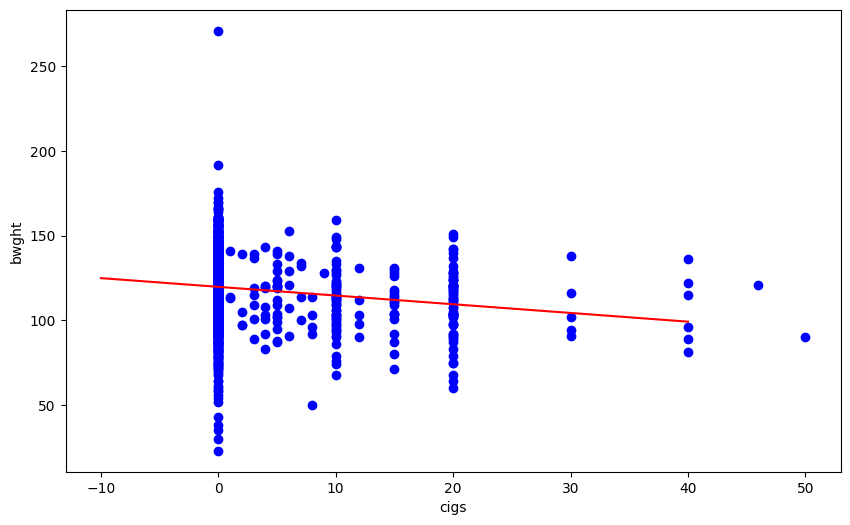

In [5]:
x = np.linspace(-10, 40, 100) 
y = 119.77 - 0.514 * x

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, color='red')
plt.scatter(birthweight_data["cigs"], birthweight_data["bwght"], color='blue')
plt.xlabel('cigs')
plt.ylabel('bwght')
plt.show()

#### Aufgabe b)

Ohne Python: Wenn das Familieneinkommen in das Modell aus (a) Modell hinzugefügt würde, welches Vorzeichen würde der Koeffizient für diese neue Variable wahrscheinlich haben?

**Antwort:**  Ein höheres Einkommen kann allgemein zu einer besseren vorgeburtlichen Betreuung oder einer besseren Ernährung der Mutter führen. Dies könnte dann die Gesundheit des Babys im Vergleich zu Frauen mit geringerem Einkommen (und daher weniger Zugang zu hochwertiger Schwangerschaftsvorsorge und besserer Ernährung) verbessern. Unter der Annahme, dass gesunde Babys ein höheres Geburtsgewicht haben als weniger gesunde, sollten wir davon ausgehen, dass ein höheres Familieneinkommen zu einem höheren Geburtsgewicht führen sollte (positive Korrelation). Dies würde bedeuten, dass der Koeffizient der unabhängigen Variable faminc positiv sein sollte, so dass ein Anstieg des Familieneinkommens auch zu einem Anstieg des Geburtsgewichts führen würde.

Glaubt ihr, dass die Anzahl der Zigaretten und das Familieneinkommen korreliert sind? Ist diese Korrelation positiv oder negativ?

**Antwort:** Einerseits macht ein Anstieg des Einkommens Zigaretten erschwinglicher, und Zigaretten und Familieneinkommen könnten positiv korreliert sein. Wahrscheinlicher allerdings ist es, dass da das Familieneinkommen eher bei Familien mit höherer Bildung höher ist, und mehr Bildung und Zigarettenrauchen während der Schwangerschaft tendenziell **negativ korreliert**.

Überprüft eure Annahmen in Python und vergleicht das Ergebnis mit der Regression aus (a).

In [6]:
model = sm.OLS(birthweight_data["bwght"], sm.add_constant(birthweight_data[["cigs", "faminc"]])).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     21.27
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           7.94e-10
Time:                        18:22:58   Log-Likelihood:                -6130.4
No. Observations:                1388   AIC:                         1.227e+04
Df Residuals:                    1385   BIC:                         1.228e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        116.9741      1.049    111.512      0.000     114.916     119.032
cigs          -0.4634      0.092     -5.060      0.000      -0.643      -0.284
faminc         0.0928      0.029      3.178      0.002       0.036       0.150
==============================================================================
Omnibus:                      116.751   Durbin-Watson:                   1.922
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              619.781
Skew:                          -0.154   Prob(JB):                    2.61e-135
Kurtosis:                       6.259   Cond. No.                         67.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Der Koeffizient des Familieneinkommens ist in der Tat positiv.

In [7]:
# Korrelation
np.corrcoef(birthweight_data["cigs"], birthweight_data["faminc"])

array([[ 1.        , -0.17304493],
       [-0.17304493,  1.        ]])

Die Korrelation ist in der Tat negativ

#### Aufgabe c)
Im Modell mit allen erklärenden Variablen: Welche Einflussfaktoren haben eine statistische und praktische Signifikanz? Welche Faktoren haben einen positiven Einfluss und welchen einen negativen Einfluss? Interpretiert diese Ergebnisse.

In [8]:
# Ersetzen der fehlenden Daten durch Mittelwert
birthweight_filled_copy = birthweight_data.copy()
birthweight_filled_copy["fatheduc"] = birthweight_data["fatheduc"].fillna(birthweight_data["fatheduc"].mean())
birthweight_filled_copy["motheduc"] = birthweight_data["motheduc"].fillna(birthweight_data["motheduc"].mean())

model = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy.drop(["bwght", "bwghtlbs"], axis=1))).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     8.800
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           5.80e-13
Time:                        18:23:01   Log-Likelihood:                -6112.6
No. Observations:                1388   AIC:                         1.225e+04
Df Residuals:                    1378   BIC:                         1.230e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        104.1316     12.535      8.308      0.000      79.543     128.721
faminc         0.0553      0.035      1.600      0.110      -0.013       0.123
cigtax         0.0694      0.144      0.481      0.631      -0.214       0.353
cigprice       0.0123      0.110      0.112      0.911      -0.203       0.227
fatheduc       0.2499      0.268      0.932      0.351      -0.276       0.776
motheduc      -0.0852      0.299     -0.285      0.776      -0.672       0.501
parity         1.7731      0.603      2.938      0.003       0.589       2.957
male           3.1180      1.070      2.914      0.004       1.019       5.217
white          5.4940      1.378      3.987      0.000       2.791       8.197
cigs          -0.4891      0.092     -5.318      0.000      -0.669      -0.309
==============================================================================
Omnibus:                      122.919   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              709.514
Skew:                          -0.139   Prob(JB):                    8.53e-155
Kurtosis:                       6.492   Cond. No.                     3.22e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.22e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Note: cigprice führt zu numerischen Unstimmigkeiten oder Multkollinearität, kann hier also auch ausgelassen werden.

#### Aufgabe d)

Welche einfache Lineare Regression (nur eine erklärende Variable), kann das Geburtsgewicht am besten erklären? Visualisiert diese Beziehung. Was ist die Interpretation des Koeffizienten und des Y-Achsenabschnittes hier?

In [9]:
result = {}
for var in birthweight_filled_copy.drop(["bwght", "bwghtlbs"], axis=1).columns:
    model = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy[var])).fit()
    result[var] = np.round(model.rsquared, 5)
result

{'faminc': np.float64(0.01187),
 'cigtax': np.float64(0.00229),
 'cigprice': np.float64(0.00242),
 'fatheduc': np.float64(0.00593),
 'motheduc': np.float64(0.00478),
 'parity': np.float64(0.00297),
 'male': np.float64(0.00522),
 'white': np.float64(0.01612),
 'cigs': np.float64(0.02273)}

In [10]:
print("Highest R^2 Value:", max(result, key=result.get))

Highest R^2 Value: cigs


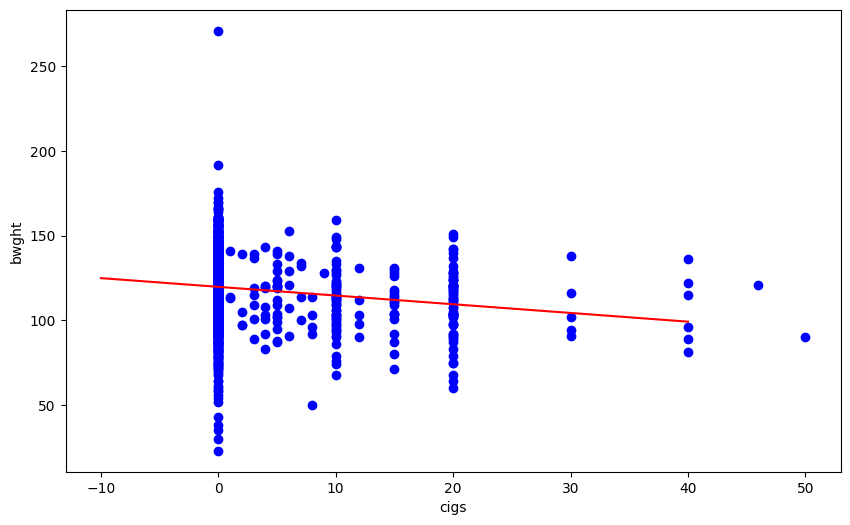

In [11]:
x = np.linspace(-10, 40, 100) 
y = 119.77 - 0.514 * x

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, color='red')
plt.scatter(birthweight_data["cigs"], birthweight_data["bwght"], color='blue')
plt.xlabel('cigs')
plt.ylabel('bwght')
plt.show()

#### Aufgabe e)

Welchen Einfluss hat das Einkommen der Familie auf das Gewicht des Kindes bei Geburt? Ist dieser Einfluss von statistisch signifikant?

In [12]:
model = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1))).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     9.906
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           1.77e-13
Time:                        18:23:03   Log-Likelihood:                -6112.6
No. Observations:                1388   AIC:                         1.224e+04
Df Residuals:                    1379   BIC:                         1.229e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        105.4645      3.878     27.196      0.000      97.857     113.072
faminc         0.0560      0.034      1.643      0.101      -0.011       0.123
cigtax         0.0836      0.069      1.207      0.228      -0.052       0.220
fatheduc       0.2497      0.268      0.932      0.352      -0.276       0.776
motheduc      -0.0864      0.299     -0.289      0.772      -0.672       0.500
parity         1.7708      0.603      2.937      0.003       0.588       2.953
male           3.1195      1.069      2.917      0.004       1.022       5.217
white          5.4866      1.376      3.988      0.000       2.788       8.185
cigs          -0.4891      0.092     -5.321      0.000      -0.669      -0.309
==============================================================================
Omnibus:                      122.977   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              710.047
Skew:                          -0.139   Prob(JB):                    6.53e-155
Kurtosis:                       6.493   Cond. No.                         312.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Positiver Einfluss, aber nicht statistisch signifikant.

#### Aufgabe f)

Welche funktionale Form des Familieneinkommens ist am besten für die Lineare Regression geeignet?

In [13]:
print("Normal: ", np.round(sm.OLS(birthweight_data["bwght"],
                                  sm.add_constant(birthweight_data["faminc"])).fit().rsquared, 4))

print("Squared: ", np.round(sm.OLS(birthweight_data["bwght"],
                                   sm.add_constant(birthweight_data["faminc"]**2)).fit().rsquared, 4))

print("Cubed: ", np.round(sm.OLS(birthweight_data["bwght"],
                                 sm.add_constant(birthweight_data["faminc"]**3)).fit().rsquared, 4))

print("Log: ", np.round(sm.OLS(birthweight_data["bwght"],
                                 sm.add_constant(np.log(birthweight_data["faminc"]))).fit().rsquared, 4))

print("Square Root: ", np.round(sm.OLS(birthweight_data["bwght"],
                                       sm.add_constant(np.sqrt(birthweight_data["faminc"]))).fit().rsquared, 4))

print("Cube Root: ", np.round(sm.OLS(birthweight_data["bwght"],
                                       sm.add_constant(np.cbrt(birthweight_data["faminc"]))).fit().rsquared, 4))


Normal:  0.0119
Squared:  0.0081
Cubed:  0.0056
Log:  0.0112
Square Root:  0.0131
Cube Root:  0.0129


Tatsächlich hat die Quadratwurzel den höchsten $R^2$ Wert.

#### Aufgabe g)
Welche Interaktionen der quantitativen Variable male sind statisch signifikant und sollten in das Modell miteinbezogen werden? Wie sind diese Interaktionen zu interpretieren?

In [14]:
result = {}
for var in birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice", "male"], axis=1).columns:
    birthweight_filled_copy["interaction"] = birthweight_filled_copy[var] * birthweight_filled_copy["male"]
    model = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1))).fit()
    result[var] = pd.read_html(io.StringIO(model.summary().as_html()))[1].iloc[10][4]
result

{'faminc': '0.501',
 'cigtax': '0.018',
 'fatheduc': '0.571',
 'motheduc': '0.077',
 'parity': '0.687',
 'white': '0.748',
 'cigs': '0.998'}

In [15]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     8.799
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           5.83e-13
Time:                        18:23:17   Log-Likelihood:                -6112.6
No. Observations:                1388   AIC:                         1.225e+04
Df Residuals:                    1378   BIC:                         1.230e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         105.4648      3.883     27.162      0.000      97.848     113.082
faminc          0.0560      0.034      1.643      0.101      -0.011       0.123
cigtax          0.0836      0.069      1.206      0.228      -0.052       0.220
fatheduc        0.2497      0.268      0.930      0.352      -0.277       0.776
motheduc       -0.0864      0.299     -0.289      0.773      -0.673       0.500
parity          1.7708      0.603      2.936      0.003       0.588       2.954
male            3.1187      1.134      2.750      0.006       0.894       5.344
white           5.4866      1.376      3.986      0.000       2.787       8.186
cigs           -0.4893      0.138     -3.548      0.000      -0.760      -0.219
interaction     0.0004      0.181      0.002      0.998      -0.354       0.355
==============================================================================
Omnibus:                      122.977   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              710.042
Skew:                          -0.139   Prob(JB):                    6.55e-155
Kurtosis:                       6.493   Cond. No.                         312.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Wir möchten evtl. die Interaktion zwischen male und cigtax zum Modell hinzufügen

In [16]:
birthweight_filled_copy["interaction"] = birthweight_filled_copy["cigtax"] * birthweight_filled_copy["male"]
model = sm.OLS(birthweight_filled_copy["bwght"],
               sm.add_constant(birthweight_filled_copy.drop(["bwght", "bwghtlbs", "cigprice"], axis=1))).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     9.457
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           4.50e-14
Time:                        18:23:18   Log-Likelihood:                -6109.8
No. Observations:                1388   AIC:                         1.224e+04
Df Residuals:                    1378   BIC:                         1.229e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         102.6422      4.051     25.337      0.000      94.695     110.589
faminc          0.0586      0.034      1.723      0.085      -0.008       0.125
cigtax          0.2412      0.096      2.512      0.012       0.053       0.430
fatheduc        0.2553      0.268      0.954      0.340      -0.270       0.780
motheduc       -0.1056      0.298     -0.354      0.723      -0.691       0.480
parity          1.6919      0.603      2.807      0.005       0.509       2.874
male            9.4635      2.886      3.280      0.001       3.803      15.124
white           5.5186      1.374      4.018      0.000       2.824       8.213
cigs           -0.4931      0.092     -5.373      0.000      -0.673      -0.313
interaction    -0.3244      0.137     -2.366      0.018      -0.593      -0.055
==============================================================================
Omnibus:                      125.204   Durbin-Watson:                   1.924
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              733.066
Skew:                          -0.147   Prob(JB):                    6.56e-160
Kurtosis:                       6.548   Cond. No.                         349.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Aufgabe h)

Hier wäre es notwendig alle Kombinationen aus Interaktionen und funktionalen Formen der verschiedenen Variablen durchzutesten (ähnlich wie oben bereits) um zu schauen ob statistisch signifikante Werte dabei sind und sich der Adjusted $R^2$ Wert noch verbessern lässt. Möglich ist es auch durch Verständnis des Falles und Logik (z.B. eher ein prozentualer Änderung erwartet, daher der Log-Value) enstpechende Änderungen vorzuschlagen und dann auf Basis der Daten zu validieren.

#### Aufgabe i)

Hier gibt es viele verschiedene Möglichkeiten mögliche weitere Daten hinzuzufügen, der Kreatitivät sind keine Grenzen gesetzt. Beispiele wären

* Alter der Mutter
* Geographische Location
* Medizinische Werte während der Schwangerschaft
* Alkoholkonsum

#### Aufgabe j)

Kreative Lösungen inkl. Interpretation der Ergebnisse

### Aufgabe 2

Beschreibt jeweils zwei reale Anwendungen von Maschinellem Lernen, bei denen Klassifizierung / Regression / Clustering nützlich sein könnte. Beschreibt dabei sowohl die Output- und mögliche Input Variablen und ob der Fokus auf Vorhersage oder Inferenz liegt.

**Beispielantworten:**
* Anwendung: Kundensegmentierung
* Technick: Clustering
* Fokus: Vorhersage
* Input: Sozioökomische Faktoren, Region, historisches Kaufverhalten
* Output: Kundengruppen

___
* Anwendung: Social Media Sentiment Analyse
* Technick: Klassifizierung
* Fokus: Vorhersage
* Input: Text der Beiträge, Anzahl der Likes, Shares, Kommentare
* Output: Sentiment (Positiv, Neutral, Negativ)

### Aufgabe 3

Was misst der $R^2$ Wert? Ist eine Regression nutzlos wenn dieser Wert gering ist?

**Antwort** Der $R^2$ Wert liegt zwischen 0 und 1 und misst den Anteil der Varianz in der abhängigen Variable, der durch die unabhängigen Variablen im Modell erklärt wird. Wir berechnen ihn durch:

$$ R^2 = 1 - \frac{SSR}{SST}$$

Eine Regression ist nicht nutzlos wenn der Wert gering ist, diese Betrachtung ist immer in Hinblick auf die Modelldefinition (wie viele Inputvariablen), die Daten (wie viele Datensätze, wie viel Varianz in der Outputvariable), und das Ziel der Analyse (Vorhersage, Inferenz) zu treffen.

### Aufgabe 4
Angenommen das wahre Modell für Wert von Bildung ist:

$$wage= \beta_0+ \beta_1 exper+ \beta_2 exper^2$$

Was ist die Konsequenz wenn wir die Regression ohne den Quadratischen Teil modellieren?

**Antwort:** Dies wäre ein Fall von Ommitted Variable Bias. Falls $\beta_2 \approx 0$, hat dies keine Konsequenz, wenn aber $\beta_2 != 0$ wäre, ist unser Modell keine gute Abbildung der Realität mehr. Die anderen im Modell enthaltenen Koeffizienten werden biased (sind etweder zu groß oder zu klein, Richtung des Bias hängt hier vom theoretischen Vorzeichen von $\beta_0$ ab), was bedeutet das unsere Interpretation der Bedeutung (Inferenz) auch nicht mehr passend ist. Gleichzeitig kann das einfachere Modell die in Wahrheit komplexere Funktion vergleichsweise schlechter abbilden, die Vorhersagen des Modell werden also auch schlechter (je nach Wert von $\beta_2$ und auch von $exper$ entweder höher oder niedriger als der Wert im besseren Modell). 

### Aufgabe 5
Was sind Möglichkeiten die akademische Ausbildung einer Person als kategorische oder numerische Variable abzubilden? Warum könnte eine kategorische / ordinale Modellierung bevorzugt werden?

**Antwort:** Während wir in den bisherigen Modellen die Variable $educ$ immer als numerische Variable dargestellt haben (Jahre an akademischer Ausbildung), ist eine kategorische Variable in der Praxis hier vermutlich besser geignet. Eine Möglichkeit für Deutschland wäre den Schulabschluss kategorisch darzustellen:

- Kein Schulabschluss
- Schulabschluss
- Ausbildung
- Bachelor
- Master
- Doktor

Auch hier gibt es natürlich verschiedene Möglichkeiten (z.B. Aufteilung des Schulabschlusses in Deutschland nach Hauptschulabschluss, Mittlerer Schulabschluss, Fachholschulreife, Hochschulreife). In anderen Ländern wären vermutlich andere spezifische Kategorien genutzt, allgemein lassen sich Daten durch die Nutzung von Kategorien allerdings häufig einfacher vergleichen.

Aspekte wie viele Jahre Personen für den selben Bachelorabschluss gebraucht haben (z.B. länger als Regelstudienzeit), werden durch die numerische Abbildung z.B. nicht passend berücksichtigt. Zusätzlich kann die Interpretierbarkeit oftmals bei kategorischen Variablen höher sein, gleichzeitig besteht aber durch die Umwandlung durchaus auch Informationsverlust.
Oftmals werden Daten auch nur in kategorischer und nicht numerischer Form gesammelt (z.B. Altersgruppen), auch um einzelne Personen nicht aus den Daten identifizieren zu können und so den Datenschutz zu berücksichtigen.

Ob nun die kategorische oder numerische Abbildung eine besser Darstellung der Variable "Education" einer Person ist, ist aber ein Punkt offen für Diskussionen, und es gibt keine eindeutige richtige Antwort.

### Aufgabe 6

Für einen Datensatz mit fünf Input-Variablen, X1 = Notendurchschnitt, X2 = IQ, X3 = Level (1 für Universität und 0 für Gymnasium), X4 = Interaktion zwischen Notendurchschnitt und IQ und X5 = Interaktion zwischen Notendurchschnitt und Level. Die Output-Variable ist das Anfangsgehalt nach dem Abschluss. Das Ergebnis der Linearen Regression ist: $\beta_0=50, \beta_1=20,\beta_2=0,007, \beta_3=35, \beta_4=0,001 \text{ und } \beta_5= −10$

a) Was ist das Gehalt eines Universitätsabsolventen mit einem IQ von 110 und einem Notendurchschnitt von 4,0?

b) Richtig oder falsch: Da der Koeffizient für den Interaktionsterm von Notendurschnitt und IQ sehr klein ist, gibt es nur sehr wenige Hinweise auf einen Interaktionseffekt. Begründet eure Antwort.

**Antwort:** Es hilft das Modell einmal in traditioneller Form zu schreiben:

$$wage = 50 + 20 * Note + 0.007 * IQ + 35 * Level + 0.001 * (Noten * IQ) -10 * (Note * Level)$$

a) Wir können die Werte in das Modell eingeben und ausrechnen:

$$wage = 50 + 20 * 4 + 0.007 * 110 + 35 * 1 + 0.001 * (4 * 110) -10 * (4 * 1) = 126.2$$

b) Allgemein ist die Größe des des Koeffizienten alleine kein ausreichender Indikator für die statistische oder ökonomische Signifikanz einer Variable, da hier auch immer die Größe des Standarderrors und die Skala der Variable eine wichtige Rolle spielen. Da wir hier den Stanardfehler nicht kennen, können wir so nicht sagen, dass der Interaktionsterm statistisch nicht signifikant ist. Für die praktische Signifikanz kann die Variable normalerweise Werte zwischen 70 und 650 annehmen, wobei hier also eine praktischer Gehaltsunterschied von 4€ ensteht, ein Wert bei dem sowohl für als auch gegen eine praktische Signifikanz argumentiert werden kann.

### Aufgabe 7
Angenommen es gibt eine Lineare Regression mit drei unabhängigen Variablen:

$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$$

Wie lässt sich durch Umschreiben und Reparametrisierung des Modell die Hypothese $H_0: \beta_1 - 3\beta_2 = 1$ einfach testen?

**Antwort:** Wir definieren $\theta = \beta_1 - 3\beta_2$ und daher dann durch umschreiben $\beta_1 = \theta + 3\beta_2$. Wenn wir diesen Term für $\beta_1$ in das Modell einfügen, erhalten wir:
$$y = \beta_0 + (\theta + 3\beta_2)x_1 + \beta_2x_2 + \beta_3x_3$$
$$y = \beta_0 + \theta x_1 + \beta_2(3x_1 + x_2) + \beta_3x_3$$

Der letzte Term wäre dann die Basis für die Lineare Regression, wobei wir die Daten entsprechend der Variablen in der Gleichung anpassen würden (durch die berechnung von $3 * x_1 + x_2$ als Inputvariable für den Koeffizienten $\beta_2$). Der vorher deutlich komplexere Hypothesentest ist nun ein infacher Test von $\theta = 1$, was wir zwar nicht einfach aus dem Modelloutput ablesen können, aber durch einen einfachen T-test auf basis des Wertes und Standardfehlers des Koeffizienten einfach berechnen können.